In [1]:
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import seaborn as sns; from sklearn.preprocessing import StandardScaler, OneHotEncoder; from sklearn.cluster import KMeans, DBSCAN; from sklearn.compose import ColumnTransformer; from sklearn.mixture import GaussianMixture; from sklearn.decomposition import PCA; from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
df = pd.read_csv('repair_invoice_clean.csv')

In [3]:
df.head()

,repair_id,claim_id,vehicle_id,repair_shop_contact_id,estimate_amount,approved_amount,invoice_amount,paid_amount,repair_start_date,repair_end_date,...,exposure_status,is_repeat_vehicle,is_synthetic_anomaly,anomaly_type,vehicle_claim_count,repair_duration_days,vehicle_age,invoice_vs_estimate_ratio,invoice_vs_approved_ratio,duplicate_flag
0,1,1,5749,217,883.00,859.88,821.28,779.60,2025-11-16,2025-11-18,...,Open,False,False,NaN,1,2,13,0.930102,0.955110,True
1,2,2,1818,152,1659.62,1620.74,1627.69,1621.15,2026-02-23,2026-03-02,...,Closed,False,False,NaN,1,7,6,0.980761,1.004288,False
2,7,6,4529,175,1013.25,844.58,917.77,820.13,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,0.905769,1.086658,False
3,8,6,4529,175,1231.42,1213.63,1417.89,1211.47,2026-04-06,2026-04-12,...,Open,False,False,NaN,1,6,3,1.151427,1.168305,False
4,9,7,7329,180,2946.86,3039.04,2827.41,2918.91,2025-11-23,2025-11-29,...,Closed,False,False,NaN,1,6,4,0.959465,0.930363,False


In [4]:
NUMERIC_FEATURES = [
   "invoice_amount", "estimate_amount",
   "vehicle_age", "liability_percentage",
]
CATEGORICAL_FEATURES = [
   "make", "damage_severity", "claim_severity", "incident_type",
   "incident_state", "coverage_type",
]

In [5]:
preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])

In [6]:
X = preprocessor.fit_transform(df)
X = X.toarray() if hasattr(X, "toarray") else X

Choosing k

In [7]:
k_range = range(2, 21)
inertias = []

In [8]:
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, lbl))

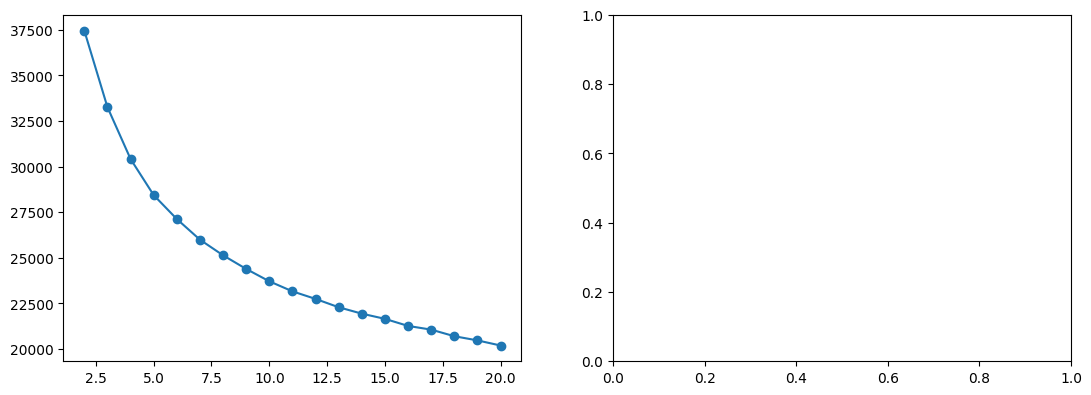

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5)); axes[0].plot(list(k_range), inertias, marker="o")

In [10]:
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")

Text(0.5, 4.444444444444445, 'k')

In [11]:
axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")

In [12]:
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")

Text(0.5, 4.444444444444445, 'k')

In [13]:
axes[1].set_ylabel("Silhouette score"); plt.tight_layout(); plt.show(); best_k = list(k_range)[int(np.argmax(silhouettes))]

<Figure size 640x480 with 0 Axes>

In [14]:
print(f"k with highest silhouette score: {best_k} ({max(silhouettes):.3f})")

k with highest silhouette score: 2 (0.254)


In [15]:
N_CLUSTERS = 14  # swap to `best_k` above if you want to follow the silhouette-optimal value
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)

In [16]:
labels = kmeans.fit_predict(X)
distances = np.linalg.norm(X - kmeans.cluster_centers_[labels], axis=1)

In [17]:
df["cluster"] = labels
df["kmeans_flag"] = False

In [18]:
cluster_thresholds = {}  # per-cluster 95th-percentile distance, reused later to score new points
for c in np.unique(labels):
    mask = labels == c
    threshold = np.quantile(distances[mask], 0.95)
    cluster_thresholds[c] = threshold
    df.loc[mask & (distances > threshold), "kmeans_flag"] = True

In [19]:
df['kmeans_flag'].value_counts()

kmeans_flag
False    6129
True      327
Name: count, dtype: int64

Evaluation metrics

In [20]:
sil = silhouette_score(X, labels)
db = davies_bouldin_score(X, labels)
ch = calinski_harabasz_score(X, labels)

In [21]:
print(f"Silhouette score:        {sil:.3f}")
print(f"Davies-Bouldin index:    {db:.3f}")
print(f"Calinski-Harabasz index: {ch:.1f}")

Silhouette score:        0.102
Davies-Bouldin index:    2.111
Calinski-Harabasz index: 531.5


In [22]:
cluster_sizes = df["cluster"].value_counts().sort_index()
cluster_sizes.name = "count"

In [23]:
cluster_sizes.to_frame()

,count
cluster,
0,737
1,420
2,820
3,262
4,293
5,516
6,454
7,513
8,559


Visualization

In [24]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

In [25]:
df["pca_1"] = X_2d[:, 0]
df["pca_2"] = X_2d[:, 1]

In [26]:
explained = pca.explained_variance_ratio_
print(f"Explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, total={explained.sum():.1%}")

Explained variance: PC1=29.4%, PC2=14.3%, total=43.8%


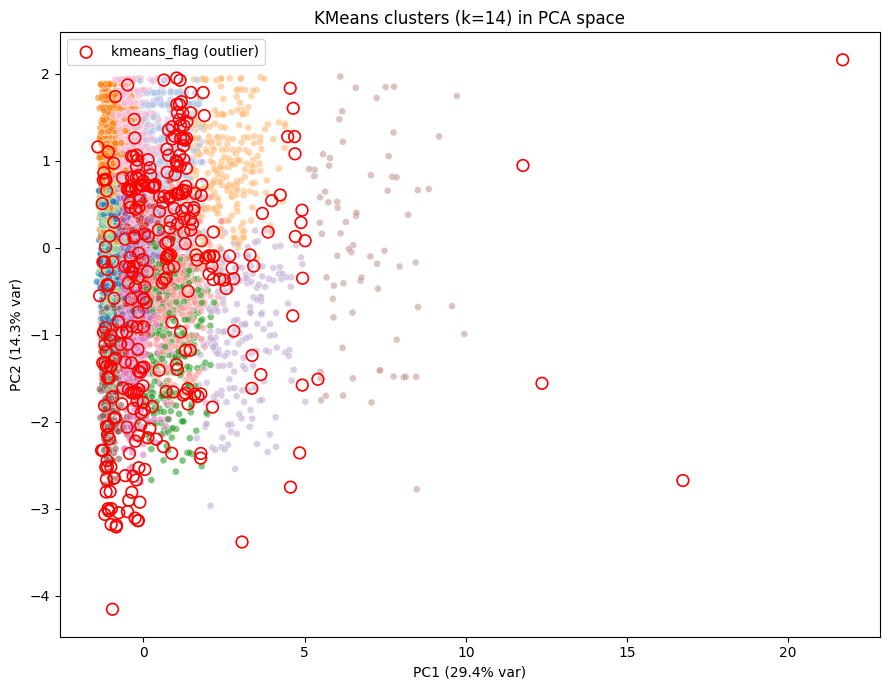

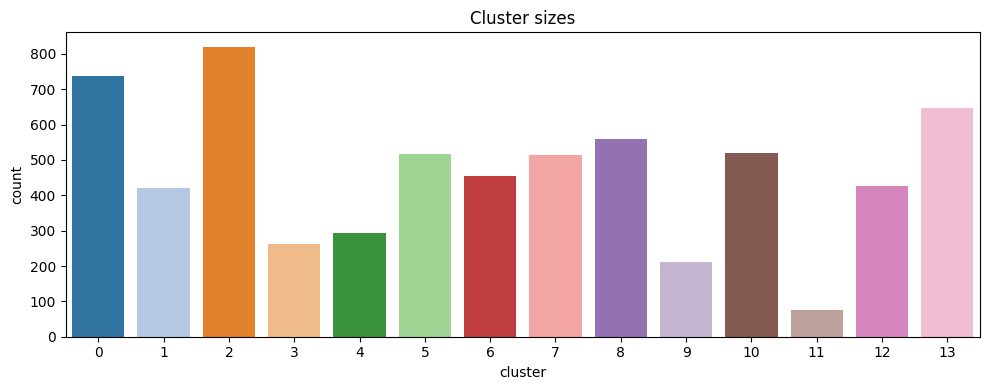

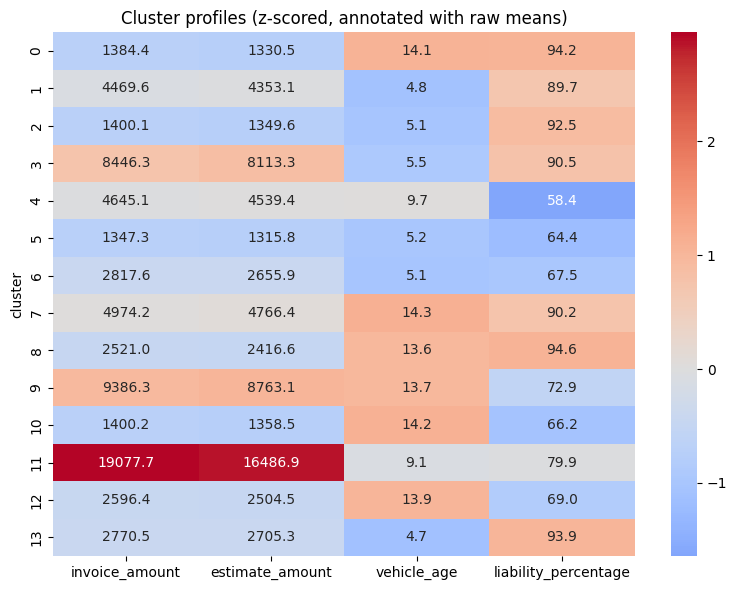

In [27]:
fig, ax = plt.subplots(figsize=(9, 7)); normal = df[~df["kmeans_flag"]]; flagged = df[df["kmeans_flag"]]; sns.scatterplot(
    data=normal, x="pca_1", y="pca_2", hue="cluster",
    palette="tab20", s=25, alpha=0.6, legend=False, ax=ax,
); ax.scatter(
    flagged["pca_1"], flagged["pca_2"],
    facecolors="none", edgecolors="red", s=70, linewidths=1.2,
    label="kmeans_flag (outlier)",
); ax.set_title(f"KMeans clusters (k={N_CLUSTERS}) in PCA space"); ax.set_xlabel(f"PC1 ({explained[0]:.1%} var)"); ax.set_ylabel(f"PC2 ({explained[1]:.1%} var)"); ax.legend(); plt.tight_layout(); plt.show(); fig, ax = plt.subplots(figsize=(10, 4)); sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, hue=cluster_sizes.index, palette="tab20", legend=False, ax=ax); ax.set_title("Cluster sizes"); ax.set_xlabel("cluster"); ax.set_ylabel("count"); plt.tight_layout(); plt.show(); profile = df.groupby("cluster")[NUMERIC_FEATURES].mean(); fig, ax = plt.subplots(figsize=(8, 6)); sns.heatmap(
    (profile - profile.mean()) / profile.std(),
    cmap="coolwarm", center=0, annot=profile.round(1), fmt="", ax=ax,
); ax.set_title("Cluster profiles (z-scored, annotated with raw means)"); plt.tight_layout(); plt.show()

Anomaly-flag sanity checks

In [28]:
ct = pd.crosstab(df["kmeans_flag"], df["duplicate_flag"], normalize="index")
print("duplicate_flag rate within each kmeans_flag group:")

duplicate_flag rate within each kmeans_flag group:


In [29]:
print(ct.round(3))
overlap_rate = df.loc[df["kmeans_flag"], "duplicate_flag"].mean()

duplicate_flag  False  True 
kmeans_flag                 
False           0.919  0.081
True            0.948  0.052


In [30]:
base_rate = df["duplicate_flag"].mean()
print(f"\nduplicate_flag rate among kmeans-flagged rows: {overlap_rate:.1%}")


duplicate_flag rate among kmeans-flagged rows: 5.2%


duplicate_flag rate overall:                  8.0%


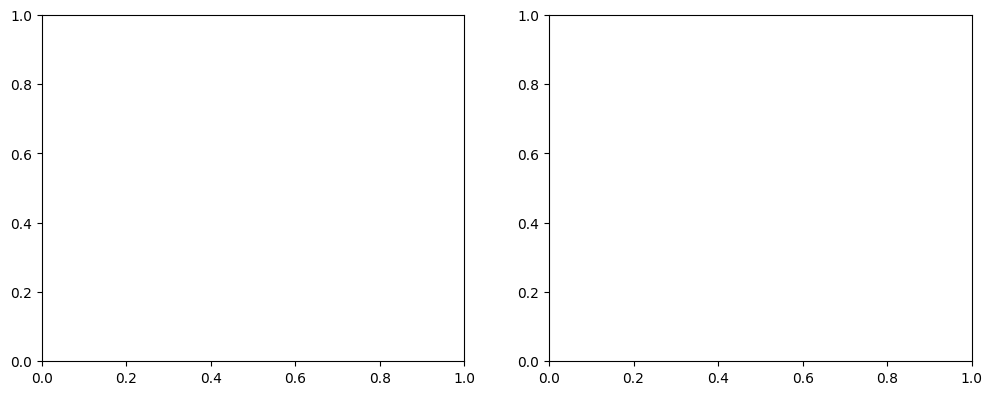

In [31]:
print(f"duplicate_flag rate overall:                  {base_rate:.1%}"); fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

In [32]:
for ax, col in zip(axes, ["invoice_vs_estimate_ratio", "invoice_vs_approved_ratio"]):
    sns.boxplot(data=df, x="kmeans_flag", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [33]:
plt.show()

Scoring a new data point

In [34]:
def score_new_point(record: dict) -> dict:
    """Score a single new repair-invoice record against the fitted KMeans model.

    `record` must contain the same NUMERIC_FEATURES + CATEGORICAL_FEATURES keys
    used to fit `preprocessor`.
    """
    row = pd.DataFrame([record])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

    x_new = preprocessor.transform(row)
    x_new = x_new.toarray() if hasattr(x_new, "toarray") else x_new

    cluster = int(kmeans.predict(x_new)[0])
    distance = float(np.linalg.norm(x_new[0] - kmeans.cluster_centers_[cluster]))
    threshold = cluster_thresholds[cluster]
    flagged = distance > threshold

    return {
        "cluster": cluster,
        "distance": distance,
        "cluster_threshold": threshold,
        "distance_over_threshold_pct": (distance / threshold - 1) * 100,
        "kmeans_flag": flagged,
        "pca_coords": pca.transform(x_new)[0].tolist(),
    }

In [35]:
typical_point = {
    "invoice_amount": 2320.00,
    "estimate_amount": 2265.50,
    "vehicle_age": 9,
    "liability_percentage": 85.0,
    "make": "Toyota",
    "damage_severity": "Moderate",
    "claim_severity": "Medium",
    "incident_type": "Vehicle Accident",
    "incident_state": "CA",
    "coverage_type": "Liability",
}
suspicious_point = {
    "invoice_amount": 18250.00,   # invoice ~7.6x the estimate for "Minor" damage
    "estimate_amount": 2400.00,
    "vehicle_age": 2,
    "liability_percentage": 22.0,
    "make": "Tesla",
    "damage_severity": "Minor",
    "claim_severity": "Low",
    "incident_type": "Vehicle Accident",
    "incident_state": "CA",
    "coverage_type": "Liability",
}

In [36]:
for name, point in [("typical_point", typical_point), ("suspicious_point", suspicious_point)]:
    result = score_new_point(point)
    print(f"--- {name} ---")
    for k, v in result.items():
        if k == "pca_coords":
            continue
        print(f"  {k}: {v}")
    print()

--- typical_point ---
  cluster: 8
  distance: 1.7230697657334408
  cluster_threshold: 1.9374352635248624
  distance_over_threshold_pct: -11.064395380179926
  kmeans_flag: False

--- suspicious_point ---
  cluster: 4
  distance: 5.7542150549375775
  cluster_threshold: 2.61687906668173
  distance_over_threshold_pct: 119.88845905034773
  kmeans_flag: True



<Axes: xlabel='pca_1', ylabel='pca_2'>

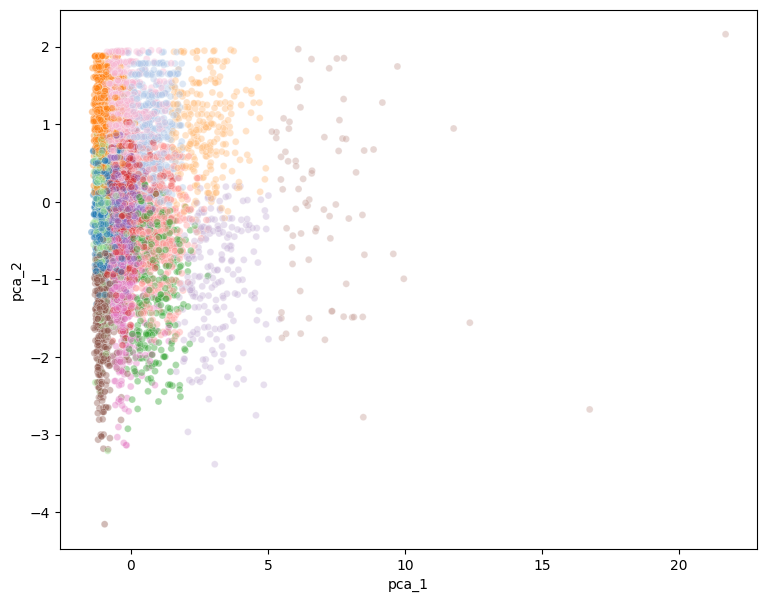

In [37]:
fig, ax = plt.subplots(figsize=(9, 7)); sns.scatterplot(
    data=df, x="pca_1", y="pca_2", hue="cluster",
    palette="tab20", s=25, alpha=0.4, legend=False, ax=ax,
)

In [38]:
for name, point, marker, color in [
    ("typical_point", typical_point, "*", "limegreen"),
    ("suspicious_point", suspicious_point, "X", "red"),
]:
    r = score_new_point(point)
    px, py = r["pca_coords"]
    ax.scatter(px, py, marker=marker, s=400, color=color, edgecolors="black", linewidths=1, label=f"{name} (flag={r['kmeans_flag']})", zorder=5)
ax.set_title("New points scored against fitted clusters")

Text(0.5, 1.0, 'New points scored against fitted clusters')

In [39]:
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(); plt.tight_layout(); plt.show()

<Figure size 640x480 with 0 Axes>